# Notebook 4 — ML Modeling
### Crash Risk Intelligence System
**Goal:** Build machine learning models to predict:
1. Injury Severity — how bad is the crash?
2. Driver At Fault — who caused the crash?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

print("Libraries imported successfully")

Libraries imported successfully


In [3]:
# Load final dataset from Notebook 3
df = pd.read_csv('C:/crash_risk_intelligence/data/featured_crash_data.csv', low_memory=False)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Rows: 215,034
Columns: 64


## Model 1 — Injury Severity Prediction
Predicting how severe the injuries are in a crash.
This is a multiclass classification problem with classes:
No Apparent Injury, Possible Injury, Minor Injury, Serious Injury, Fatal

In [4]:
# Features to use for modeling
features = [
    'Crash Hour', 'Is Weekend', 'Is Rush Hour', 'Is Night',
    'Is High Risk Weather', 'Is High Risk Light', 'Is High Speed',
    'Is Driver At Fault', 'Is Substance Abuse', 'Is Distracted',
    'Vehicle Age', 'Is Old Vehicle', 'Is Severe Damage',
    'Speed Limit', 'Weather Encoded', 'Light Encoded',
    'Surface Condition Encoded', 'Collision Type Encoded',
    'Vehicle Body Type Encoded', 'Vehicle Movement Encoded'
]

# Target variable
target = 'Injury Severity Encoded'

X = df[features]
y = df[target]

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nTarget classes:")
print(df['Injury Severity'].value_counts())

Features shape: (215034, 20)
Target shape: (215034,)

Target classes:
Injury Severity
No Apparent Injury          174212
Possible Injury              20349
Suspected Minor Injury       15474
Unknown                       3052
Suspected Serious Injury      1746
Fatal Injury                   201
Name: count, dtype: int64


In [5]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 80% training, 20% testing
    random_state=42,    # for reproducibility
    stratify=y          # maintain class proportions in both sets
)

print(f"Training set size: {X_train.shape[0]:,}")
print(f"Testing set size: {X_test.shape[0]:,}")
print(f"\nTraining set — 80% of data")
print(f"Testing set — 20% of data")

Training set size: 172,027
Testing set size: 43,007

Training set — 80% of data
Testing set — 20% of data


## Training Random Forest Model
Random Forest is a tree based ensemble model.
It builds multiple decision trees and combines their
predictions for a more accurate and stable result.
It works well with imbalanced data and does not require scaling.

In [6]:
# Train Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,    # number of trees
    max_depth=10,        # limit tree depth to avoid overfitting
    random_state=42,
    class_weight='balanced',  # handles imbalanced classes
    n_jobs=-1            # use all CPU cores for speed
)

print("Training model... this may take a minute")
rf_model.fit(X_train, y_train)
print("Model training complete!")

Training model... this may take a minute
Model training complete!


In [7]:
# Make predictions on test set
y_pred = rf_model.predict(X_test)

# Accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2%}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=df['Injury Severity'].unique()))

Model Accuracy: 47.91%

Detailed Classification Report:
                          precision    recall  f1-score   support

                 Unknown       0.03      0.42      0.05        40
      No Apparent Injury       0.92      0.49      0.64     34843
         Possible Injury       0.16      0.40      0.22      4070
  Suspected Minor Injury       0.13      0.36      0.19      3095
Suspected Serious Injury       0.04      0.26      0.06       349
            Fatal Injury       0.28      0.96      0.44       610

                accuracy                           0.48     43007
               macro avg       0.26      0.48      0.27     43007
            weighted avg       0.77      0.48      0.56     43007



In [8]:
# Remove Unknown class from dataset
df_clean = df[df['Injury Severity'] != 'Unknown'].copy()

# Reencode target without Unknown
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_clean['Injury Severity Encoded'] = le.fit_transform(df_clean['Injury Severity'])

# Recreate X and y
X = df_clean[features]
y = df_clean['Injury Severity Encoded']

# Retrain test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set size: {X_train.shape[0]:,}")
print(f"Testing set size: {X_test.shape[0]:,}")
print(f"\nTarget classes after removing Unknown:")
print(df_clean['Injury Severity'].value_counts())

Training set size: 169,585
Testing set size: 42,397

Target classes after removing Unknown:
Injury Severity
No Apparent Injury          174212
Possible Injury              20349
Suspected Minor Injury       15474
Suspected Serious Injury      1746
Fatal Injury                   201
Name: count, dtype: int64


In [9]:
# Retrain Random Forest model without Unknown class
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

print("Training model...")
rf_model.fit(X_train, y_train)

# Evaluate
y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.2%}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Training model...
Model Accuracy: 50.37%

Detailed Classification Report:
                          precision    recall  f1-score   support

            Fatal Injury       0.03      0.35      0.05        40
      No Apparent Injury       0.92      0.53      0.67     34843
         Possible Injury       0.16      0.40      0.22      4070
  Suspected Minor Injury       0.13      0.39      0.19      3095
Suspected Serious Injury       0.04      0.28      0.07       349

                accuracy                           0.50     42397
               macro avg       0.26      0.39      0.24     42397
            weighted avg       0.78      0.50      0.59     42397



In [10]:
# Install imbalanced-learn if not already installed
import subprocess
subprocess.run(['pip', 'install', 'imbalanced-learn', '--quiet'])

from imblearn.over_sampling import SMOTE

# Apply SMOTE to balance classes
print("Applying SMOTE to balance classes...")
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"Training set size before SMOTE: {X_train.shape[0]:,}")
print(f"Training set size after SMOTE: {X_train_balanced.shape[0]:,}")
print(f"\nClass distribution after SMOTE:")
unique, counts = np.unique(y_train_balanced, return_counts=True)
for u, c in zip(le.classes_, counts):
    print(f"  {u}: {c:,}")

Applying SMOTE to balance classes...
Training set size before SMOTE: 169,585
Training set size after SMOTE: 696,845

Class distribution after SMOTE:
  Fatal Injury: 139,369
  No Apparent Injury: 139,369
  Possible Injury: 139,369
  Suspected Minor Injury: 139,369
  Suspected Serious Injury: 139,369


In [11]:
# Retrain with balanced data
rf_model_balanced = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,        # increased depth
    random_state=42,
    n_jobs=-1
)

print("Training model on balanced data... this may take a few minutes")
rf_model_balanced.fit(X_train_balanced, y_train_balanced)

# Evaluate on original test set
y_pred_balanced = rf_model_balanced.predict(X_test)
accuracy_balanced = accuracy_score(y_test, y_pred_balanced)

print(f"Model Accuracy: {accuracy_balanced:.2%}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_balanced, target_names=le.classes_))

Training model on balanced data... this may take a few minutes
Model Accuracy: 64.57%

Detailed Classification Report:
                          precision    recall  f1-score   support

            Fatal Injury       0.04      0.25      0.07        40
      No Apparent Injury       0.86      0.74      0.79     34843
         Possible Injury       0.15      0.26      0.19      4070
  Suspected Minor Injury       0.15      0.19      0.16      3095
Suspected Serious Injury       0.03      0.11      0.05       349

                accuracy                           0.65     42397
               macro avg       0.25      0.31      0.25     42397
            weighted avg       0.73      0.65      0.68     42397



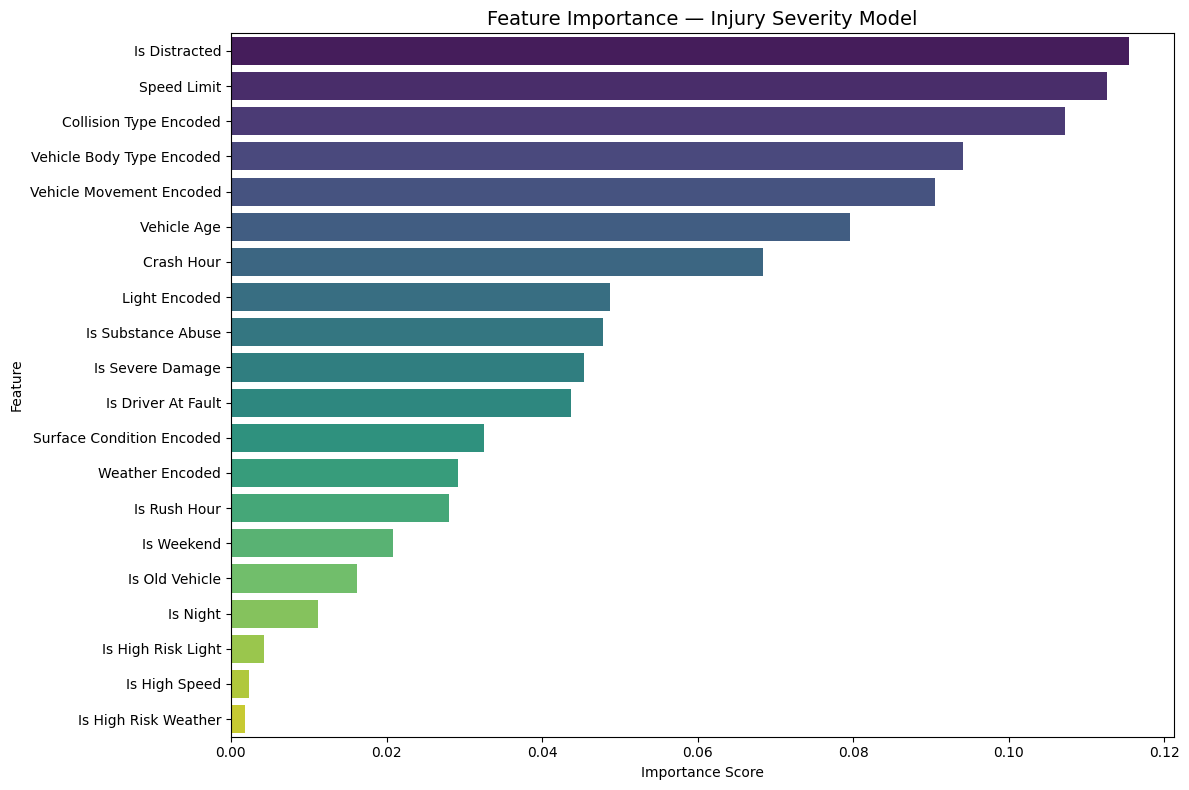


Top 5 most important features:
                      Feature  Importance
9               Is Distracted    0.115417
13                Speed Limit    0.112577
17     Collision Type Encoded    0.107200
18  Vehicle Body Type Encoded    0.094161
19   Vehicle Movement Encoded    0.090536


In [12]:
# Plot feature importance
importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model_balanced.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(data=importance, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance — Injury Severity Model', fontsize=14)
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("\nTop 5 most important features:")
print(importance.head())

In [ ]:
# Confusion matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred_balanced)
sns.heatmap(cm, 
            annot=True, 
            fmt='d',
            cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Confusion Matrix — Injury Severity Model', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()